In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
data  = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ['time'], index_col = 'time')

In [3]:
# data = data[:'2025-12-31']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 174153 entries, 2019-01-01 22:00:00 to 2025-12-30 23:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   174153 non-null  float64
 1   spread  174153 non-null  float64
dtypes: float64(2)
memory usage: 4.0 MB


In [5]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [6]:
window = 50

In [7]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [8]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027


In [9]:
lags = 5

In [10]:
col = []
features = ["sma", "boll", "min", "max", "mom", "vol","dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace = True)

In [11]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027,...,0.00027,0.00028,0.00030,0.00030,0.00031,0.00000,1.00000,1.00000,1.00000,1.00000
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027,...,0.00027,0.00027,0.00028,0.00030,0.00030,0.00000,0.00000,1.00000,1.00000,1.00000
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027,...,0.00027,0.00027,0.00027,0.00028,0.00030,1.00000,0.00000,0.00000,1.00000,1.00000


In [12]:
len(col)

35

In [13]:
len(df)

173999

In [14]:
# split = int(len(df)*0.66)
# split

In [15]:
train = df.loc["2023-01-01":"2024-12-31"].copy()
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,1.06998,0.00100,-0.00038,0,0.00201,0.74330,-0.00475,0.00107,-0.00015,0.00069,...,0.00068,0.00070,0.00070,0.00070,0.00071,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:15:00,1.07000,0.00100,0.00002,1,0.00205,0.72739,-0.00477,0.00106,-0.00008,0.00068,...,0.00069,0.00068,0.00070,0.00070,0.00070,0.00000,1.00000,0.00000,1.00000,0.00000
2023-01-01 23:30:00,1.07008,0.00050,0.00007,1,0.00209,0.74670,-0.00484,0.00098,-0.00010,0.00067,...,0.00068,0.00069,0.00068,0.00070,0.00070,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:45:00,1.07057,0.00050,0.00046,1,0.00211,1.02400,-0.00530,0.00052,0.00018,0.00067,...,0.00067,0.00068,0.00069,0.00068,0.00070,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-02 00:00:00,1.07052,0.00050,-0.00005,0,0.00214,0.95257,-0.00525,0.00057,0.00016,0.00067,...,0.00067,0.00067,0.00068,0.00069,0.00068,1.00000,1.00000,1.00000,0.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 20:45:00,1.03585,0.00014,-0.00015,0,-0.00193,-0.85601,-0.00114,0.00596,0.00003,0.00047,...,0.00047,0.00047,0.00047,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2024-12-31 21:00:00,1.03596,0.00017,0.00011,1,-0.00198,-0.78089,-0.00125,0.00585,-0.00005,0.00047,...,0.00047,0.00047,0.00047,0.00047,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
2024-12-31 21:15:00,1.03586,0.00016,-0.00010,0,-0.00206,-0.78623,-0.00115,0.00595,-0.00005,0.00045,...,0.00047,0.00047,0.00047,0.00047,0.00047,1.00000,0.00000,0.00000,1.00000,1.00000


In [16]:
test = df.loc["2025-01-01":"2025-12-30"].copy()
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 22:00:00,1.03526,0.00087,-0.00007,0,-0.00230,-0.92195,-0.00057,0.00638,-0.00019,0.00044,...,0.00045,0.00045,0.00045,0.00047,0.00047,0.00000,0.00000,0.00000,1.00000,0.00000
2025-01-01 22:15:00,1.03559,0.00058,0.00032,1,-0.00238,-0.75655,-0.00089,0.00604,-0.00007,0.00044,...,0.00044,0.00045,0.00045,0.00045,0.00047,0.00000,0.00000,0.00000,0.00000,1.00000
2025-01-01 22:30:00,1.03575,0.00026,0.00015,1,-0.00246,-0.65839,-0.00104,0.00588,0.00014,0.00044,...,0.00044,0.00044,0.00045,0.00045,0.00045,1.00000,0.00000,0.00000,0.00000,0.00000
2025-01-01 22:45:00,1.03568,0.00041,-0.00007,0,-0.00252,-0.65774,-0.00098,0.00595,0.00014,0.00044,...,0.00044,0.00044,0.00044,0.00045,0.00045,1.00000,1.00000,0.00000,0.00000,0.00000
2025-01-01 23:00:00,1.03539,0.00018,-0.00028,0,-0.00259,-0.75455,-0.00070,0.00623,-0.00006,0.00044,...,0.00044,0.00044,0.00044,0.00044,0.00045,0.00000,1.00000,1.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027,...,0.00027,0.00028,0.00030,0.00030,0.00031,0.00000,1.00000,1.00000,1.00000,1.00000
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027,...,0.00027,0.00027,0.00028,0.00030,0.00030,0.00000,0.00000,1.00000,1.00000,1.00000
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027,...,0.00027,0.00027,0.00027,0.00028,0.00030,1.00000,0.00000,0.00000,1.00000,1.00000


In [17]:
train[col] 

,sma_lag1,sma_lag2,sma_lag3,sma_lag4,sma_lag5,boll_lag1,boll_lag2,boll_lag3,boll_lag4,boll_lag5,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,0.00197,0.00192,0.00190,0.00189,0.00188,1.01976,0.97905,1.13027,1.14211,1.28481,...,0.00068,0.00070,0.00070,0.00070,0.00071,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:15:00,0.00201,0.00197,0.00192,0.00190,0.00189,0.74330,1.01976,0.97905,1.13027,1.14211,...,0.00069,0.00068,0.00070,0.00070,0.00070,0.00000,1.00000,0.00000,1.00000,0.00000
2023-01-01 23:30:00,0.00205,0.00201,0.00197,0.00192,0.00190,0.72739,0.74330,1.01976,0.97905,1.13027,...,0.00068,0.00069,0.00068,0.00070,0.00070,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-01 23:45:00,0.00209,0.00205,0.00201,0.00197,0.00192,0.74670,0.72739,0.74330,1.01976,0.97905,...,0.00067,0.00068,0.00069,0.00068,0.00070,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-02 00:00:00,0.00211,0.00209,0.00205,0.00201,0.00197,1.02400,0.74670,0.72739,0.74330,1.01976,...,0.00067,0.00067,0.00068,0.00069,0.00068,1.00000,1.00000,1.00000,0.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 20:45:00,-0.00187,-0.00182,-0.00176,-0.00170,-0.00165,-0.83065,-0.82380,-0.99356,-1.13943,-1.13797,...,0.00047,0.00047,0.00047,0.00047,0.00047,0.00000,1.00000,1.00000,0.00000,0.00000
2024-12-31 21:00:00,-0.00193,-0.00187,-0.00182,-0.00176,-0.00170,-0.85601,-0.83065,-0.82380,-0.99356,-1.13943,...,0.00047,0.00047,0.00047,0.00047,0.00047,0.00000,0.00000,1.00000,1.00000,0.00000
2024-12-31 21:15:00,-0.00198,-0.00193,-0.00187,-0.00182,-0.00176,-0.78089,-0.85601,-0.83065,-0.82380,-0.99356,...,0.00047,0.00047,0.00047,0.00047,0.00047,1.00000,0.00000,0.00000,1.00000,1.00000


In [18]:
mu, std = train.mean(), train.std()

In [19]:
std

price       0.01697
spread      0.00006
returns     0.00044
dir         0.50000
sma         0.00219
boll        1.43256
min         0.00193
max         0.00209
mom         0.00025
vol         0.00019
sma_lag1    0.00219
sma_lag2    0.00219
sma_lag3    0.00219
sma_lag4    0.00219
sma_lag5    0.00219
boll_lag1   1.43256
boll_lag2   1.43256
boll_lag3   1.43256
boll_lag4   1.43257
boll_lag5   1.43257
min_lag1    0.00193
min_lag2    0.00193
min_lag3    0.00193
min_lag4    0.00193
min_lag5    0.00193
max_lag1    0.00209
max_lag2    0.00209
max_lag3    0.00209
max_lag4    0.00209
max_lag5    0.00209
mom_lag1    0.00025
mom_lag2    0.00025
mom_lag3    0.00025
mom_lag4    0.00025
mom_lag5    0.00025
vol_lag1    0.00019
vol_lag2    0.00019
vol_lag3    0.00019
vol_lag4    0.00019
vol_lag5    0.00019
dir_lag1    0.50000
dir_lag2    0.50000
dir_lag3    0.50000
dir_lag4    0.50000
dir_lag5    0.50000
dtype: float64

In [20]:
train_s = (train - mu) / std
train_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 23:00:00,-0.69888,13.95140,-0.86961,-0.99444,0.92953,0.50479,-1.46635,-0.40658,-0.58035,1.53663,...,1.52401,1.62534,1.62765,1.62959,1.67684,1.00553,-0.99448,1.00549,-0.99448,1.00549
2023-01-01 23:15:00,-0.69771,13.95140,0.04402,1.00557,0.94961,0.49369,-1.47600,-0.41553,-0.31989,1.50396,...,1.53657,1.52394,1.62527,1.62758,1.62952,-0.99448,1.00553,-0.99452,1.00553,-0.99452
2023-01-01 23:30:00,-0.69299,5.62708,0.17152,1.00557,0.96532,0.50716,-1.51459,-0.45130,-0.38188,1.47335,...,1.50390,1.53651,1.52388,1.62521,1.62751,1.00553,-0.99448,1.00549,-0.99448,1.00549
2023-01-01 23:45:00,-0.66412,5.62708,1.04249,1.00557,0.97827,0.70073,-1.75085,-0.67028,0.73442,1.46435,...,1.47329,1.50383,1.53644,1.52381,1.62514,1.00553,1.00553,-0.99452,1.00553,-0.99452
2023-01-02 00:00:00,-0.66706,5.62708,-0.10468,-0.99444,0.99082,0.65088,-1.72676,-0.64794,0.64761,1.45208,...,1.46430,1.47323,1.50377,1.53638,1.52375,1.00553,1.00553,1.00549,-0.99448,1.00549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 20:45:00,-2.71000,-0.36643,-0.34968,-0.99444,-0.86852,-0.61161,0.40544,1.92673,0.11798,0.38654,...,0.39336,0.39335,0.37592,0.37661,0.40549,-0.99448,1.00553,1.00549,-0.99448,-0.99452
2024-12-31 21:00:00,-2.70352,0.13303,0.24297,1.00557,-0.89460,-0.55917,0.35043,1.87567,-0.20237,0.37414,...,0.38651,0.39332,0.39331,0.37589,0.37657,-0.99448,-0.99448,1.00549,1.00553,-0.99452
2024-12-31 21:15:00,-2.70941,-0.03346,-0.21798,-0.99444,-0.92847,-0.56290,0.40044,1.92209,-0.18958,0.27920,...,0.37410,0.38647,0.39328,0.39328,0.37585,1.00553,-0.99448,-0.99452,1.00553,1.00549


In [21]:
train_s.describe()

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
count,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,...,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000,49807.00000
mean,0.00000,0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.00000,-0.00000,0.00000,...,0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000
std,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
min,-2.81901,-0.86589,-22.66746,-0.99444,-4.92890,-4.59774,-7.98021,-0.92030,-17.87573,-1.57306,...,-1.57305,-1.57304,-1.57303,-1.57301,-1.57299,-0.99448,-0.99448,-0.99452,-0.99448,-0.99452
25%,-0.62817,-0.36643,-0.40900,-0.99444,-0.58209,-0.72825,-0.38152,-0.67772,-0.40991,-0.70076,...,-0.70077,-0.70078,-0.70079,-0.70080,-0.70080,-0.99448,-0.99448,-0.99452,-0.99448,-0.99452
50%,0.08600,-0.19994,0.00152,-0.99444,0.01081,0.02095,0.27822,-0.30131,0.01495,-0.21001,...,-0.21003,-0.21005,-0.21007,-0.21009,-0.21011,-0.99448,-0.99448,-0.99452,-0.99448,-0.99452
75%,0.63636,-0.03346,0.42085,1.00557,0.57223,0.73473,0.69353,0.35798,0.42637,0.44779,...,0.44780,0.44778,0.44777,0.44779,0.44782,1.00553,1.00553,1.00549,1.00553,1.00549
max,2.67163,13.95140,15.10285,1.00557,5.01272,4.25479,0.99633,9.74452,12.43673,8.13688,...,8.13668,8.13644,8.13620,8.13597,8.13573,1.00553,1.00553,1.00549,1.00553,1.00549


In [22]:
from DNNModel import *

In [23]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(col))
model.fit(x = train_s[col], y = train["dir"], epochs = 50, verbose = False,
          validation_split = 0.2, shuffle = False, class_weight = cw(train))

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.evaluate(train_s[col], train["dir"])

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.5271 - loss: 0.6917


[0.691656768321991, 0.5270745158195496]

In [25]:
pred = model.predict(train_s[col])
pred

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step


array([[0.5178586 ],
       [0.49998865],
       [0.51143956],
       ...,
       [0.5016922 ],
       [0.5031996 ],
       [0.5007827 ]], shape=(49807, 1), dtype=float32)

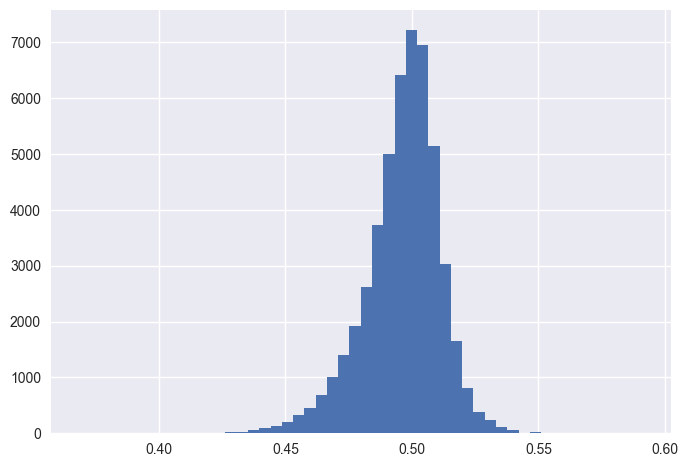

In [26]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [27]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 22:00:00,1.03526,0.00087,-0.00007,0,-0.00230,-0.92195,-0.00057,0.00638,-0.00019,0.00044,...,0.00045,0.00045,0.00045,0.00047,0.00047,0.00000,0.00000,0.00000,1.00000,0.00000
2025-01-01 22:15:00,1.03559,0.00058,0.00032,1,-0.00238,-0.75655,-0.00089,0.00604,-0.00007,0.00044,...,0.00044,0.00045,0.00045,0.00045,0.00047,0.00000,0.00000,0.00000,0.00000,1.00000
2025-01-01 22:30:00,1.03575,0.00026,0.00015,1,-0.00246,-0.65839,-0.00104,0.00588,0.00014,0.00044,...,0.00044,0.00044,0.00045,0.00045,0.00045,1.00000,0.00000,0.00000,0.00000,0.00000
2025-01-01 22:45:00,1.03568,0.00041,-0.00007,0,-0.00252,-0.65774,-0.00098,0.00595,0.00014,0.00044,...,0.00044,0.00044,0.00044,0.00045,0.00045,1.00000,1.00000,0.00000,0.00000,0.00000
2025-01-01 23:00:00,1.03539,0.00018,-0.00028,0,-0.00259,-0.75455,-0.00070,0.00623,-0.00006,0.00044,...,0.00044,0.00044,0.00044,0.00044,0.00045,0.00000,1.00000,1.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027,...,0.00027,0.00028,0.00030,0.00030,0.00031,0.00000,1.00000,1.00000,1.00000,1.00000
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027,...,0.00027,0.00027,0.00028,0.00030,0.00030,0.00000,0.00000,1.00000,1.00000,1.00000
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027,...,0.00027,0.00027,0.00027,0.00028,0.00030,1.00000,0.00000,0.00000,1.00000,1.00000


In [28]:
test_s = (test - mu) / std
test_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 22:00:00,-2.74476,11.78708,-0.15222,-0.99444,-1.03649,-0.65764,0.70072,2.13150,-0.76650,0.22509,...,0.29124,0.27564,0.27910,0.37399,0.38636,-0.99448,-0.99448,-0.99452,1.00553,-0.99452
2025-01-01 22:15:00,-2.72532,6.95897,0.72621,1.00557,-1.07654,-0.54218,0.53552,1.96437,-0.29216,0.24940,...,0.22506,0.29120,0.27561,0.27907,0.37396,-0.99448,-0.99448,-0.99452,-0.99448,1.00549
2025-01-01 22:30:00,-2.71589,1.63141,0.35280,1.00557,-1.10969,-0.47366,0.45547,1.89008,0.54104,0.23301,...,0.24937,0.22503,0.29117,0.27558,0.27903,1.00553,-0.99448,-0.99452,-0.99448,-0.99452
2025-01-01 22:45:00,-2.72002,4.12870,-0.15216,-0.99444,-1.13984,-0.47321,0.49049,1.92258,0.54108,0.23092,...,0.23298,0.24933,0.22499,0.29114,0.27554,1.00553,1.00553,-0.99452,-0.99448,-0.99452
2025-01-01 23:00:00,-2.73710,0.29952,-0.63526,-0.99444,-1.16988,-0.54079,0.63563,2.05725,-0.25376,0.23466,...,0.23089,0.23295,0.24930,0.22496,0.29110,-0.99448,1.00553,1.00549,-0.99448,-0.99452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,5.46940,1.46492,-0.26947,-0.99444,-0.38476,-0.87605,0.88152,0.27193,-0.20077,-0.67094,...,-0.66700,-0.60793,-0.55100,-0.55046,-0.48287,-0.99448,1.00553,1.00549,1.00553,1.00549
2025-12-30 23:00:00,5.48354,0.13303,0.46605,1.00557,-0.40027,-0.66099,0.77559,0.11302,0.03653,-0.67970,...,-0.67095,-0.66701,-0.60794,-0.55101,-0.55047,-0.99448,-0.99448,1.00549,1.00553,1.00549
2025-12-30 23:15:00,5.47529,0.46600,-0.26944,-0.99444,-0.41544,-0.76711,0.83738,0.17011,-0.04256,-0.68217,...,-0.67971,-0.67096,-0.66702,-0.60795,-0.55103,1.00553,-0.99448,-0.99452,1.00553,1.00549


In [29]:
model.evaluate(test_s[col], test["dir"])

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step - accuracy: 0.5106 - loss: 0.6930


[0.6930298805236816, 0.5106151103973389]

In [30]:
pred = model.predict(train_s[col])
pred

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step


array([[0.5178586 ],
       [0.49998865],
       [0.51143956],
       ...,
       [0.5016922 ],
       [0.5031996 ],
       [0.5007827 ]], shape=(49807, 1), dtype=float32)

(array([1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 3.000e+00,
        2.000e+00, 3.000e+00, 4.000e+00, 4.000e+00, 6.000e+00, 9.000e+00,
        1.200e+01, 1.900e+01, 3.000e+01, 6.400e+01, 8.600e+01, 1.290e+02,
        1.940e+02, 3.210e+02, 4.500e+02, 6.840e+02, 1.010e+03, 1.410e+03,
        1.929e+03, 2.628e+03, 3.733e+03, 5.005e+03, 6.421e+03, 7.222e+03,
        6.948e+03, 5.145e+03, 3.029e+03, 1.649e+03, 8.150e+02, 3.820e+02,
        2.320e+02, 1.170e+02, 5.300e+01, 1.200e+01, 1.600e+01, 1.100e+01,
        4.000e+00, 2.000e+00, 5.000e+00, 1.000e+00, 0.000e+00, 3.000e+00,
        0.000e+00, 1.000e+00]),
 array([0.36834002, 0.37279707, 0.37725413, 0.38171118, 0.38616827,
        0.39062533, 0.39508238, 0.39953944, 0.4039965 , 0.40845355,
        0.41291064, 0.4173677 , 0.42182475, 0.42628181, 0.43073887,
        0.43519592, 0.43965298, 0.44411007, 0.44856712, 0.45302418,
        0.45748124, 0.46193829, 0.46639538, 0.47085243, 0.47530949,
        0.47976655, 0.4842236 , 0.48

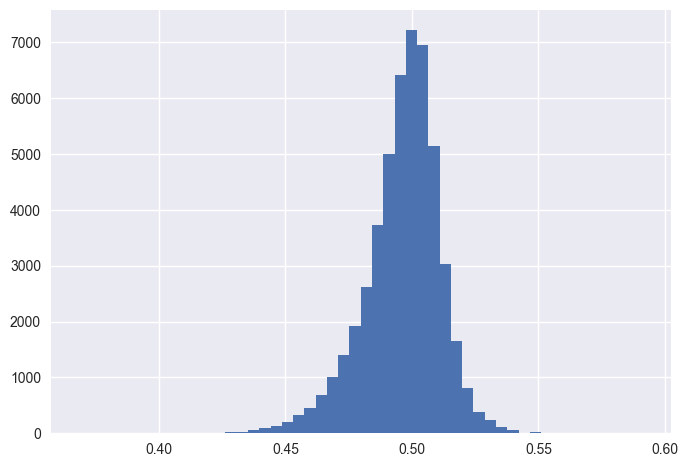

In [31]:
plt.hist(pred, bins = 50)

In [32]:
test['proba'] = model.predict(test_s[col])  

775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step


In [33]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [34]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [35]:
test["hour"] = test.index.hour

In [36]:
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position) # 3. neutral in non-busy hours

In [37]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [38]:
test.position.value_counts(dropna = False)

position
0.00000     22380
-1.00000     1993
1.00000       403
Name: count, dtype: int64

In [39]:
test["strategy"] = test["position"] * test["returns"]

In [40]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

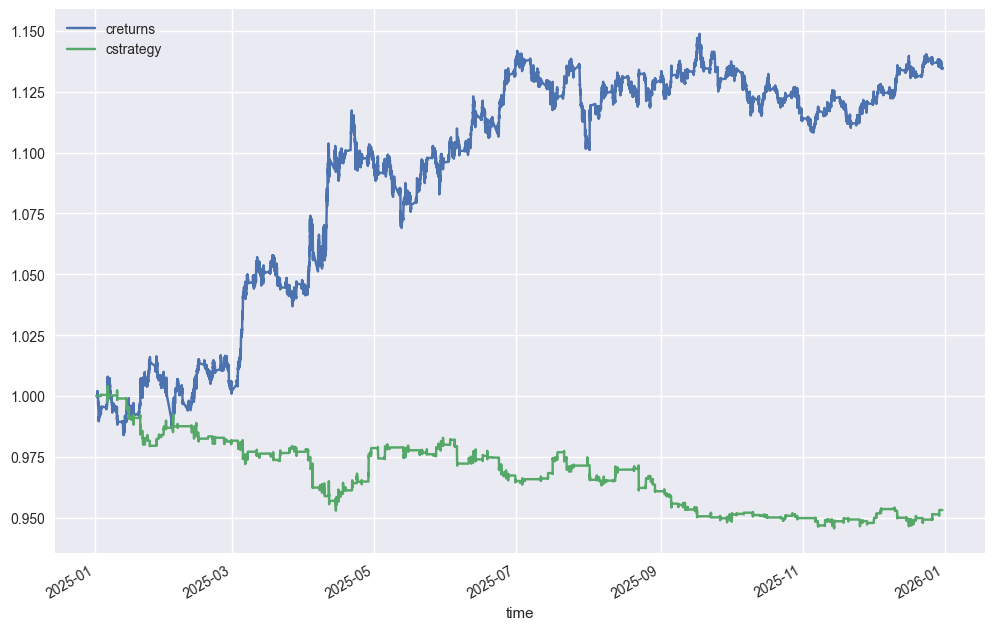

In [41]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [42]:
ptc = 0.00005 

In [43]:
test['trades'] = test.position.diff().abs()

In [44]:
test['trades'].value_counts()

trades
0.00000    24383
1.00000      356
2.00000       36
Name: count, dtype: int64

In [45]:
test['strategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

In [46]:
test['cstrategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

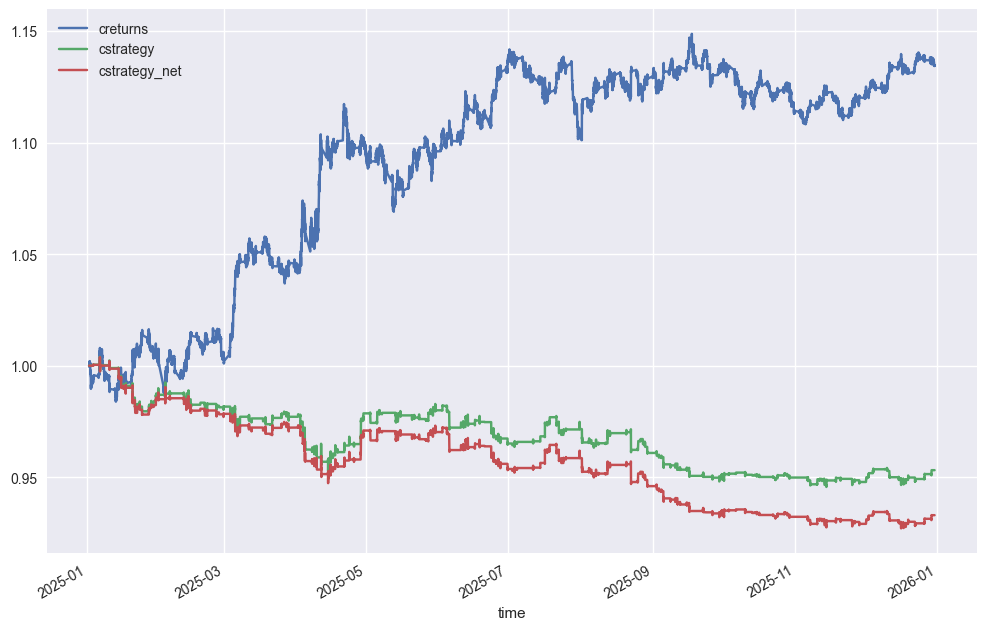

In [47]:
test[['creturns', 'cstrategy', 'cstrategy_net']].plot(figsize = (12, 8))
plt.show()


## XAI Decision Filtering Gate (SHAP)

This section adds a **risk-management gate** in front of the DNN’s trade decisions.

- The DNN produces a position signal (`test["position"]`) at every timestamp.
- A trade only happens when the position **changes** (captured by `test["trades"]`).
- The XAI gate runs **only at trade events** and uses **local SHAP feature importance** to decide whether a *new entry* is sufficiently well-explained.
- **Exits are always allowed** (reduces risk); **entries are filtered** (reduces low-quality / weakly-explained trades).

Outcome: we get a new position series `test["position_xai"]` and a net equity curve `test["cstrategy_net_xai"]` to compare against the baseline `test["cstrategy_net"]`.

In [48]:
# If needed:
# !pip install shap

import shap

# Gate hyperparameters (tune these)
TOP_N = 3
N_BACKGROUND = 200         # SHAP background sample size
N_CALIB = 800             # number of entry/flip events used to calibrate threshold
SHAP_QUANTILE = 0.60      # keep only the strongest ~25% explanations (higher => fewer trades)
PROBA_MARGIN = 0      # additional confidence margin around 0.5 for allowing entries
EXCLUDE_TOP1_PREFIXES = ("dir_",)  # treat these as weak/less-informative top drivers


# Build SHAP explainer on training distribution
background = train_s[col].sample(N_BACKGROUND, random_state=42).values
explainer = shap.DeepExplainer(model, background)


def _extract_shap_vector(shap_values):
    """Return a 1D SHAP vector for the (single) model output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr).reshape(-1)


def _top_shap_summary(instance_1d, *, top_n=TOP_N):
    """Compute local SHAP summary for one instance."""
    instance_2d = instance_1d.reshape(1, -1)
    shap_values = explainer.shap_values(instance_2d, check_additivity=False)
    sv = _extract_shap_vector(shap_values)

    abs_sv = np.abs(sv)
    top_idx = np.argsort(abs_sv)[::-1][:top_n]
    top_features = [col[int(i)] for i in top_idx]
    top_shap = sv[top_idx]

    return {
        "sv": sv,
        "sv_sum": float(sv.sum()),
        "top_idx": top_idx,
        "top_features": top_features,
        "top_shap": [float(x) for x in top_shap],
        "top_abs": [float(x) for x in abs_sv[top_idx]],
        "top1_abs": float(abs_sv[top_idx[0]]),
    }


def calibrate_shap_threshold(test_df, test_scaled, *, quantile=SHAP_QUANTILE, n_calib=N_CALIB):
    """
    Calibrate an absolute-SHAP threshold from the distribution of top-1 SHAP magnitudes
    on (a sample of) entry/flip events.

    Higher threshold => fewer trades (stricter risk filter).
    """
    # Events where the baseline strategy changes position AND desires a non-zero position
    trade_event = test_df["trades"].fillna(0) > 0
    entry_like = trade_event & (test_df["position"].fillna(0) != 0)
    event_idx = test_df.index[entry_like]

    if len(event_idx) == 0:
        return 0.0

    # Sample for speed
    if len(event_idx) > n_calib:
        event_idx = event_idx[:n_calib]

    top1_abs_list = []
    for idx in event_idx:
        instance = test_scaled.loc[idx, col].values
        summ = _top_shap_summary(instance, top_n=TOP_N)
        top1_abs_list.append(summ["top1_abs"])

    thr = float(np.quantile(np.array(top1_abs_list), quantile))
    return thr


def xai_gate_entry(instance_1d, desired_pos, proba, *, shap_threshold, top_n=TOP_N):
    """
    Decide whether to ALLOW a *new entry* (desired_pos in {-1, +1}) based on local SHAP.

    Checks:
    - confidence: proba must be far enough from 0.5 (PROBA_MARGIN)
    - explanation strength: top-1 |SHAP| must exceed calibrated shap_threshold
    - explanation direction: sum(SHAP) should align with desired direction
    - explanation quality: avoid trivial top driver(s) like dir_lag* (optional)

    Returns: allow(bool), info(dict)
    """
    desired_pos = int(desired_pos)
    proba = float(proba)

    # Confidence check (acts like a second-stage filter)
    if desired_pos == 1:
        proba_ok = proba >= (0.5 + PROBA_MARGIN)
    else:
        proba_ok = proba <= (0.5 - PROBA_MARGIN)

    summ = _top_shap_summary(instance_1d, top_n=top_n)
    sv_sum = summ["sv_sum"]

    direction_ok = (desired_pos == 1 and sv_sum > 0) or (desired_pos == -1 and sv_sum < 0)
    magnitude_ok = summ["top1_abs"] >= float(shap_threshold)

    top1 = summ["top_features"][0]
    top1_ok = not any(top1.startswith(p) for p in EXCLUDE_TOP1_PREFIXES)

    allow = bool(proba_ok and direction_ok and magnitude_ok and top1_ok)

    info = {
        "proba": proba,
        "desired_pos": desired_pos,
        "sv_sum": sv_sum,
        "top_features": summ["top_features"],
        "top_shap": summ["top_shap"],
        "top_abs": summ["top_abs"],
        "top1_abs": summ["top1_abs"],
        "proba_ok": bool(proba_ok),
        "direction_ok": bool(direction_ok),
        "magnitude_ok": bool(magnitude_ok),
        "top1_ok": bool(top1_ok),
        "shap_threshold": float(shap_threshold),
    }
    return allow, info


def format_gate_explanation(prev_pos, desired_pos, final_pos, info, allow):
    tf = info.get("top_features", [])
    ts = info.get("top_shap", [])
    parts = [
        f"prev={prev_pos}, desired={desired_pos}, final={final_pos}",
        f"proba={info.get('proba', np.nan):.3f}, shap_sum={info.get('sv_sum', np.nan):+.4f}, top1_abs={info.get('top1_abs', np.nan):.4f}",
        f"shap_threshold={info.get('shap_threshold', np.nan):.4f}",
        "top features: " + ", ".join([f"{f}({v:+.4f})" for f, v in zip(tf, ts)]),
        f"checks: proba={info.get('proba_ok')} direction={info.get('direction_ok')} magnitude={info.get('magnitude_ok')} top1_ok={info.get('top1_ok')}",
        "DECISION: " + ("ALLOW" if allow else "DENY"),
    ]
    return "\n".join(parts)

d:\anaconda3\envs\mlops_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda3\envs\mlops_test\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


In [49]:
# Apply XAI gate only when the baseline strategy would trade
pos_target = test["position"].copy()

# ---------------------------
# FIX FOR DATA LEAKAGE / SNOOPING
# ---------------------------
# DO NOT calibrate SHAP threshold on the test set.
# Instead, calibrate on a "calibration" slice taken from the training period.
# This keeps the test year purely out-of-sample for the XAI gate evaluation.

CALIB_FRAC = 0.20  # last 20% of train used for calibration
calib_start = int(len(train) * (1 - CALIB_FRAC))
calib = train.iloc[calib_start:].copy()
calib_s = (calib - mu) / std

# Build baseline signals on calibration slice (same rules as test baseline)
PROBA_SHORT = 0.47
PROBA_LONG = 0.53
BUSY_HOUR_START = 12
BUSY_HOUR_END = 16

calib["proba"] = model.predict(calib_s[col])
calib["position"] = np.where(calib.proba < PROBA_SHORT, -1, np.nan)
calib["position"] = np.where(calib.proba > PROBA_LONG, 1, calib.position)
calib["hour"] = calib.index.hour
calib["position"] = np.where(~calib.hour.between(BUSY_HOUR_START, BUSY_HOUR_END), 0, calib.position)
calib["position"] = calib.position.ffill().fillna(0)
calib["trades"] = calib.position.diff().abs().fillna(0)

# Calibrate SHAP threshold from entry/flip events in CALIBRATION slice (not test)
SHAP_THRESHOLD = calibrate_shap_threshold(calib, calib_s, quantile=SHAP_QUANTILE, n_calib=N_CALIB)
print("Calibrated SHAP_THRESHOLD (from TRAIN calibration slice):", SHAP_THRESHOLD)

# Construct position_xai sequentially:
# - Exits to 0 are always allowed
# - Entries to +/-1 are filtered by SHAP + confidence checks
# - Flips become: exit (allowed) then optional entry (gated)

position_xai = pd.Series(index=test.index, dtype=float)
position_xai.iloc[0] = float(pos_target.iloc[0])

trade_event = test["trades"].fillna(0) > 0

gate_log = []

for i in range(1, len(test)):
    idx = test.index[i]
    prev = float(position_xai.iloc[i - 1])
    desired = float(pos_target.iloc[i])

    # Default: hold
    final_pos = prev
    action = "hold"
    allow = True

    proba = float(test.loc[idx, "proba"])
    info = {"proba": proba, "desired_pos": int(desired), "sv_sum": np.nan, "top_features": [], "top_shap": [], "top_abs": [], "top1_abs": np.nan, "proba_ok": True, "direction_ok": True, "magnitude_ok": True, "top1_ok": True, "shap_threshold": float(SHAP_THRESHOLD)}

    if trade_event.iloc[i]:
        # Model wants to change position here
        if desired == 0:
            action = "exit"
            final_pos = 0.0
            allow = True

        elif prev != 0 and np.sign(prev) != np.sign(desired):
            # Flip: always exit; entry is gated
            action = "flip"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else 0.0

        else:
            # Entry from flat, or re-entry after being flat
            action = "entry"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else prev

    position_xai.iloc[i] = final_pos

    if trade_event.iloc[i]:
        gate_log.append({
            "time": idx,
            "action": action,
            "prev_pos": prev,
            "desired_pos": desired,
            "final_pos": final_pos,
            "allow": bool(allow),
            "proba": info.get("proba", np.nan),
            "sv_sum": info.get("sv_sum", np.nan),
            "top1": info.get("top_features", [None])[0] if info.get("top_features") else None,
            "top1_abs": info.get("top1_abs", np.nan),
            "top1_shap": info.get("top_shap", [np.nan])[0] if info.get("top_shap") else np.nan,
            "proba_ok": info.get("proba_ok", True),
            "direction_ok": info.get("direction_ok", True),
            "magnitude_ok": info.get("magnitude_ok", True),
            "top1_ok": info.get("top1_ok", True),
            "shap_threshold": info.get("shap_threshold", np.nan),
            "explanation": format_gate_explanation(prev, desired, final_pos, info, allow),
        })

# Attach to test
position_xai = position_xai.ffill().fillna(0)
test["position_xai"] = position_xai

# Trades and performance with gate
test["trades_xai"] = test["position_xai"].diff().abs().fillna(0)
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["cstrategy_xai"] = test["strategy_xai"].cumsum().apply(np.exp)
test["cstrategy_net_xai"] = (test["strategy_xai"] - test["trades_xai"] * ptc).cumsum().apply(np.exp)

# Gate log table
gate_log_df = pd.DataFrame(gate_log).set_index("time")
gate_log_df.head()

312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step


d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 35))']
  warnings.warn(msg)


Calibrated SHAP_THRESHOLD (from TRAIN calibration slice): 0.01631616745198325


,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_abs,top1_shap,proba_ok,direction_ok,magnitude_ok,top1_ok,shap_threshold,explanation
time,,,,,,,,,,,,,,,,
2025-01-03 16:30:00,entry,0.00000,-1.00000,0.00000,False,0.46910,-0.02587,mom_lag5,0.01149,-0.01149,True,True,False,True,0.01632,"prev=0.0, desired=-1.0, final=0.0\nproba=0.469..."
2025-01-03 17:00:00,exit,0.00000,0.00000,0.00000,True,0.48681,NaN,None,NaN,NaN,True,True,True,True,0.01632,"prev=0.0, desired=0.0, final=0.0\nproba=0.487,..."
2025-01-06 12:30:00,entry,0.00000,1.00000,1.00000,True,0.53040,0.03543,mom_lag5,0.02397,0.02397,True,True,True,True,0.01632,"prev=0.0, desired=1.0, final=1.0\nproba=0.530,..."
2025-01-06 17:00:00,exit,1.00000,0.00000,0.00000,True,0.51357,NaN,None,NaN,NaN,True,True,True,True,0.01632,"prev=1.0, desired=0.0, final=0.0\nproba=0.514,..."
2025-01-10 13:45:00,entry,0.00000,1.00000,1.00000,True,0.53627,0.04130,mom_lag1,0.02578,0.02578,True,True,True,True,0.01632,"prev=0.0, desired=1.0, final=1.0\nproba=0.536,..."


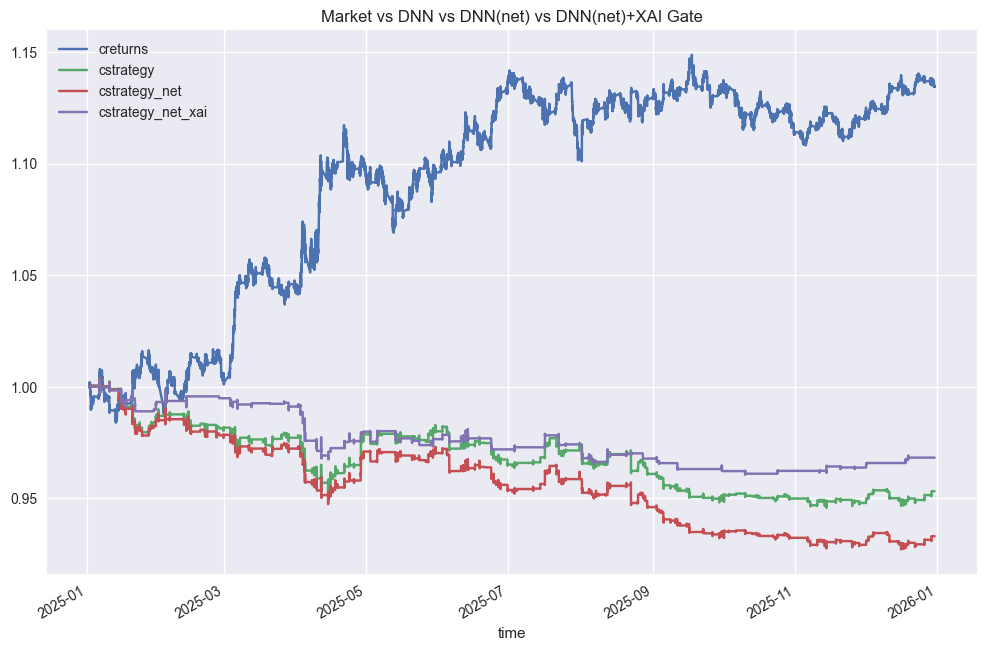

Baseline (net) ending value: 0.9329861413348131
XAI-gated (net) ending value: 0.9682030941140604
Baseline orders (sum abs pos change): 428.0
XAI orders (sum abs pos change): 170.0
Baseline trade events (bars with orders): 392
XAI trade events (bars with orders): 159
Gate evaluated events: 392
Gate allowed events: 263
Gate denied events: 129
Order reduction vs baseline: 60.28%


In [50]:
# Compare baseline vs XAI-gated strategy (net of trading costs)
compare_cols = ["creturns", "cstrategy", "cstrategy_net", "cstrategy_net_xai"]
test[compare_cols].plot(figsize=(12, 8))
plt.title("Market vs DNN vs DNN(net) vs DNN(net)+XAI Gate")
plt.show()

# Trade counts and gate stats
baseline_orders = float(test["trades"].fillna(0).sum())
xai_orders = float(test["trades_xai"].fillna(0).sum())
baseline_trade_events = int((test["trades"].fillna(0) > 0).sum())
xai_trade_events = int((test["trades_xai"].fillna(0) > 0).sum())

allowed = int(gate_log_df["allow"].sum())
denied = int((~gate_log_df["allow"]).sum())

print("Baseline (net) ending value:", float(test["cstrategy_net"].iloc[-1]))
print("XAI-gated (net) ending value:", float(test["cstrategy_net_xai"].iloc[-1]))
print("Baseline orders (sum abs pos change):", baseline_orders)
print("XAI orders (sum abs pos change):", xai_orders)
print("Baseline trade events (bars with orders):", baseline_trade_events)
print("XAI trade events (bars with orders):", xai_trade_events)
print("Gate evaluated events:", len(gate_log_df))
print("Gate allowed events:", allowed)
print("Gate denied events:", denied)

# How XAI acts as risk management
reduction = 0 if baseline_orders == 0 else 1 - (xai_orders / baseline_orders)
print("Order reduction vs baseline:", f"{reduction:.2%}")

In [51]:
# Show sample trade decisions with explanations

# Sample a few allowed and denied events (if available)
allowed_samples = gate_log_df[gate_log_df["allow"]].head(5)
denied_samples = gate_log_df[~gate_log_df["allow"]].head(5)

print("\n--- Sample ALLOWED decisions (first 5) ---")
for t, row in allowed_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

print("\n--- Sample DENIED decisions (first 5) ---")
for t, row in denied_samples.iterrows():
    print("\nTime:", t)
    
    print(row["explanation"])

# Compact table view
cols_view = ["action", "prev_pos", "desired_pos", "final_pos", "allow", "proba", "sv_sum", "top1", "top1_shap"]
gate_log_df[cols_view].head(20)


--- Sample ALLOWED decisions (first 5) ---

Time: 2025-01-03 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.487, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0163
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2025-01-06 12:30:00
prev=0.0, desired=1.0, final=1.0
proba=0.530, shap_sum=+0.0354, top1_abs=0.0240
shap_threshold=0.0163
top features: mom_lag5(+0.0240), min_lag5(+0.0149), min_lag1(-0.0111)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2025-01-06 17:00:00
prev=1.0, desired=0.0, final=0.0
proba=0.514, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0163
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2025-01-10 13:45:00
prev=0.0, desired=1.0, final=1.0
proba=0.536, shap_sum=+0.0413, top1_abs=0.0258
shap_threshold=0.0163
top features: mom_lag1(+0.0258), boll_lag1(+0.0067), dir_lag2(+0.0058)
checks: proba=True direction=True magnitude=Tru

,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_shap
time,,,,,,,,,
2025-01-03 16:30:00,entry,0.00000,-1.00000,0.00000,False,0.46910,-0.02587,mom_lag5,-0.01149
2025-01-03 17:00:00,exit,0.00000,0.00000,0.00000,True,0.48681,NaN,None,NaN
2025-01-06 12:30:00,entry,0.00000,1.00000,1.00000,True,0.53040,0.03543,mom_lag5,0.02397
2025-01-06 17:00:00,exit,1.00000,0.00000,0.00000,True,0.51357,NaN,None,NaN
2025-01-10 13:45:00,entry,0.00000,1.00000,1.00000,True,0.53627,0.04130,mom_lag1,0.02578
2025-01-10 17:00:00,exit,1.00000,0.00000,0.00000,True,0.47809,NaN,None,NaN
2025-01-14 13:45:00,entry,0.00000,-1.00000,0.00000,False,0.46717,-0.02780,mom_lag2,-0.00979
2025-01-14 17:00:00,exit,0.00000,0.00000,0.00000,True,0.50930,NaN,None,NaN
2025-01-15 13:45:00,entry,0.00000,-1.00000,-1.00000,True,0.41567,-0.07930,boll_lag1,-0.03407


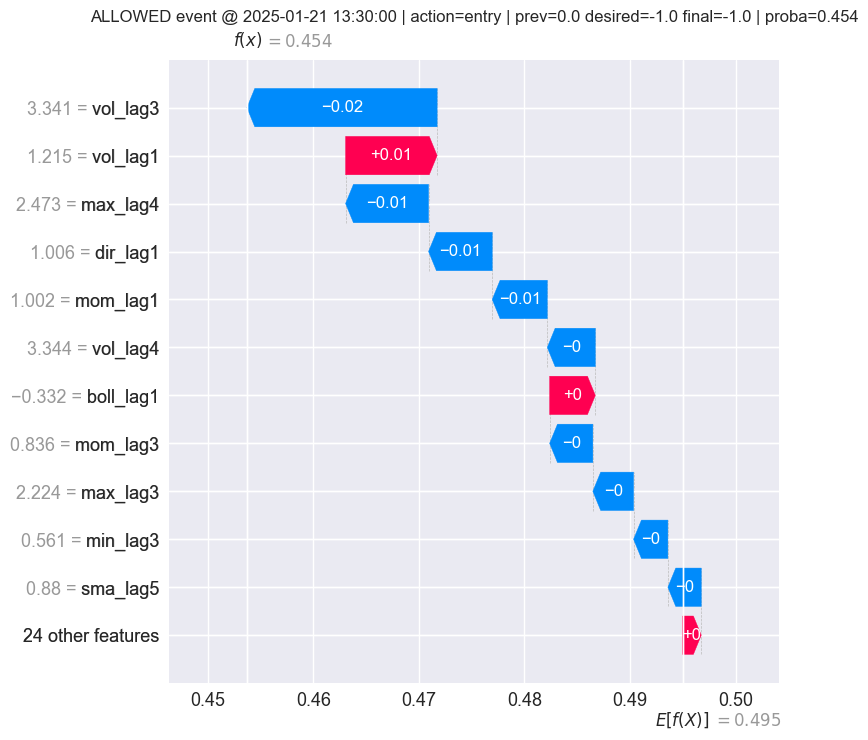


--- Explanation (ALLOWED entry/flip) ---
prev=0.0, desired=-1.0, final=-1.0
proba=0.454, shap_sum=-0.0413, top1_abs=0.0180
shap_threshold=0.0163
top features: vol_lag3(-0.0180), vol_lag1(+0.0087), max_lag4(-0.0079)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW


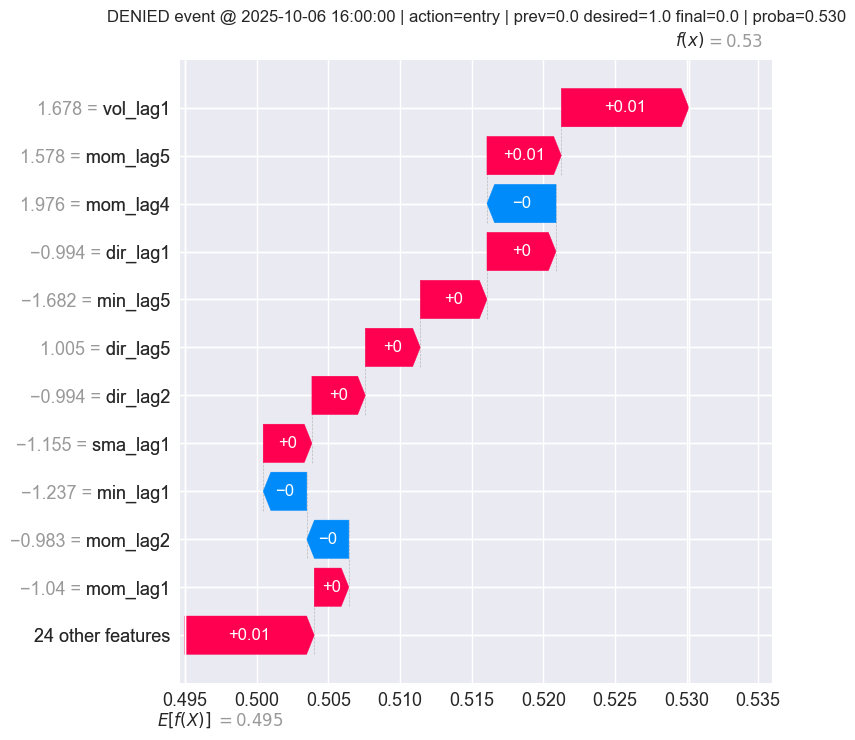


--- Explanation (DENIED entry/flip) ---
prev=0.0, desired=1.0, final=0.0
proba=0.530, shap_sum=+0.0352, top1_abs=0.0089
shap_threshold=0.0163
top features: vol_lag1(+0.0089), mom_lag5(+0.0052), mom_lag4(-0.0048)
checks: proba=True direction=True magnitude=False top1_ok=True
DECISION: DENY


In [52]:
# Waterfall plots: one random ALLOWED entry/flip and one random DENIED entry/flip

def _get_expected_value(exp):
    ev = getattr(exp, "expected_value", 0.0)
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = ev[0]
    return float(np.array(ev).reshape(()))


def waterfall_for_event(event_time, label):
    x = test_s.loc[event_time, col].values
    shap_values = explainer.shap_values(x.reshape(1, -1), check_additivity=False)
    sv = _extract_shap_vector(shap_values)
    base = _get_expected_value(explainer)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x,
        feature_names=col,
    )

    meta = gate_log_df.loc[event_time]
    title = (
        f"{label} event @ {event_time} | action={meta['action']} | "
        f"prev={meta['prev_pos']} desired={meta['desired_pos']} final={meta['final_pos']} | proba={meta['proba']:.3f}"
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(42)

# We want cases where the gate actually matters: entries or flips (not exits)
entry_like = gate_log_df["action"].isin(["entry", "flip"]) & (gate_log_df["desired_pos"].astype(float) != 0)

allowed_candidates = gate_log_df[entry_like & (gate_log_df["allow"])].index

denied_candidates = gate_log_df[entry_like & (~gate_log_df["allow"])].index

if len(allowed_candidates) > 0:
    t_allowed = allowed_candidates[rng.integers(0, len(allowed_candidates))]
    waterfall_for_event(t_allowed, "ALLOWED")
    print("\n--- Explanation (ALLOWED entry/flip) ---")
    print(gate_log_df.loc[t_allowed, "explanation"])
else:
    print("No ALLOWED entry/flip events available to plot.")

if len(denied_candidates) > 0:
    t_denied = denied_candidates[rng.integers(0, len(denied_candidates))]
    waterfall_for_event(t_denied, "DENIED")
    print("\n--- Explanation (DENIED entry/flip) ---")
    print(gate_log_df.loc[t_denied, "explanation"])
else:
    print("No DENIED entry/flip events available to plot.")

## Additional XAI Visualisations (MSc-ready)

This block produces four groups of figures:

1) **Global feature importance** (SHAP beeswarm + bar)
2) **Local explanations** (already shown above via waterfall plots)
3) **Gate behavior summary** (allowed vs denied distributions + top-driver frequency)
4) **Regime / time stability** (rolling mean absolute SHAP for top features)

Notes:
- SHAP for deep models is compute-heavy. These cells intentionally compute SHAP on a **sample** to keep runtime practical.
- To make results reproducible, a fixed RNG seed is used for sampling.

In [53]:
# ---- SHAP sampling utilities (used by multiple plots) ----

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Control how many points to explain (trade-off: quality vs runtime)
GLOBAL_SHAP_SAMPLES = 1200      # for global beeswarm+bar
REGIME_SHAP_SAMPLES = 2000      # for rolling stability
SHAP_BATCH = 200                # batch size for explainer

# Choose where to sample from:
# - For "global" interpretation across all timestamps, sample from test_s.
# - For "trade-centric" interpretation, sample from trade events only.
USE_TRADE_EVENTS_FOR_GLOBAL = False


def _extract_shap_matrix(shap_values):
    """Return a (n_samples, n_features) matrix from DeepExplainer output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr)


def compute_shap_for_index(index, *, batch_size=SHAP_BATCH):
    """
    Compute SHAP values for rows in `index` using `test_s[col]` and the global `explainer`.
    Returns: X (n, d), S (n, d)
    """
    X = test_s.loc[index, col].values
    S_chunks = []

    for start in range(0, len(index), batch_size):
        end = min(start + batch_size, len(index))
        xb = X[start:end]
        sv = explainer.shap_values(xb, check_additivity=False)
        S_chunks.append(_extract_shap_matrix(sv))

    S = np.vstack(S_chunks) if len(S_chunks) else np.empty((0, len(col)))
    return X, S


def _sample_index_from_pool(pool_index, n):
    pool_index = np.array(pool_index)
    if len(pool_index) <= n:
        return pool_index
    take = rng.choice(len(pool_index), size=n, replace=False)
    return pool_index[take]


# Build sampling pools
trade_event_idx = gate_log_df.index  # when the baseline strategy changed position
all_test_idx = test.index

global_pool = trade_event_idx if USE_TRADE_EVENTS_FOR_GLOBAL else all_test_idx

# Samples for plots
idx_global = _sample_index_from_pool(global_pool, GLOBAL_SHAP_SAMPLES)
idx_regime = _sample_index_from_pool(trade_event_idx, REGIME_SHAP_SAMPLES)

print("Global SHAP sample size:", len(idx_global), "(trade-centric:" , USE_TRADE_EVENTS_FOR_GLOBAL, ")")
print("Regime SHAP sample size:", len(idx_regime), "(trade-event-only)")

Global SHAP sample size: 1200 (trade-centric: False )
Regime SHAP sample size: 392 (trade-event-only)


In [54]:
model

<Sequential name=sequential, built=True>

In [55]:
mu

price        1.08184
spread       0.00016
returns     -0.00000
dir          0.49722
sma         -0.00003
boll         0.02016
min         -0.00192
max          0.00193
mom         -0.00000
vol          0.00040
sma_lag1    -0.00003
sma_lag2    -0.00003
sma_lag3    -0.00003
sma_lag4    -0.00003
sma_lag5    -0.00003
boll_lag1    0.02020
boll_lag2    0.02023
boll_lag3    0.02027
boll_lag4    0.02031
boll_lag5    0.02035
min_lag1    -0.00192
min_lag2    -0.00192
min_lag3    -0.00192
min_lag4    -0.00192
min_lag5    -0.00192
max_lag1     0.00193
max_lag2     0.00193
max_lag3     0.00193
max_lag4     0.00192
max_lag5     0.00192
mom_lag1    -0.00000
mom_lag2    -0.00000
mom_lag3    -0.00000
mom_lag4    -0.00000
mom_lag5    -0.00000
vol_lag1     0.00040
vol_lag2     0.00040
vol_lag3     0.00040
vol_lag4     0.00040
vol_lag5     0.00040
dir_lag1     0.49724
dir_lag2     0.49724
dir_lag3     0.49726
dir_lag4     0.49724
dir_lag5     0.49726
dtype: float64

In [56]:
std

price       0.01697
spread      0.00006
returns     0.00044
dir         0.50000
sma         0.00219
boll        1.43256
min         0.00193
max         0.00209
mom         0.00025
vol         0.00019
sma_lag1    0.00219
sma_lag2    0.00219
sma_lag3    0.00219
sma_lag4    0.00219
sma_lag5    0.00219
boll_lag1   1.43256
boll_lag2   1.43256
boll_lag3   1.43256
boll_lag4   1.43257
boll_lag5   1.43257
min_lag1    0.00193
min_lag2    0.00193
min_lag3    0.00193
min_lag4    0.00193
min_lag5    0.00193
max_lag1    0.00209
max_lag2    0.00209
max_lag3    0.00209
max_lag4    0.00209
max_lag5    0.00209
mom_lag1    0.00025
mom_lag2    0.00025
mom_lag3    0.00025
mom_lag4    0.00025
mom_lag5    0.00025
vol_lag1    0.00019
vol_lag2    0.00019
vol_lag3    0.00019
vol_lag4    0.00019
vol_lag5    0.00019
dir_lag1    0.50000
dir_lag2    0.50000
dir_lag3    0.50000
dir_lag4    0.50000
dir_lag5    0.50000
dtype: float64

In [57]:
model.save("DNN_model.keras")

In [58]:
import pickle

In [59]:
params = {"mu":mu, "std":std}

In [60]:
params

{'mu': price        1.08184
 spread       0.00016
 returns     -0.00000
 dir          0.49722
 sma         -0.00003
 boll         0.02016
 min         -0.00192
 max          0.00193
 mom         -0.00000
 vol          0.00040
 sma_lag1    -0.00003
 sma_lag2    -0.00003
 sma_lag3    -0.00003
 sma_lag4    -0.00003
 sma_lag5    -0.00003
 boll_lag1    0.02020
 boll_lag2    0.02023
 boll_lag3    0.02027
 boll_lag4    0.02031
 boll_lag5    0.02035
 min_lag1    -0.00192
 min_lag2    -0.00192
 min_lag3    -0.00192
 min_lag4    -0.00192
 min_lag5    -0.00192
 max_lag1     0.00193
 max_lag2     0.00193
 max_lag3     0.00193
 max_lag4     0.00192
 max_lag5     0.00192
 mom_lag1    -0.00000
 mom_lag2    -0.00000
 mom_lag3    -0.00000
 mom_lag4    -0.00000
 mom_lag5    -0.00000
 vol_lag1     0.00040
 vol_lag2     0.00040
 vol_lag3     0.00040
 vol_lag4     0.00040
 vol_lag5     0.00040
 dir_lag1     0.49724
 dir_lag2     0.49724
 dir_lag3     0.49726
 dir_lag4     0.49724
 dir_lag5     0.49726
 dty

In [61]:
pickle.dump(params, open("params.pkl", "wb"))

In [62]:
summary = pd.DataFrame(
    {
        "ending_value_net": [
            float(test["cstrategy_net"].iloc[-1]),
            float(test["cstrategy_net_xai"].iloc[-1]),
        ],
        "orders_sum_abs_pos_change": [
            float(test["trades"].fillna(0).sum()),
            float(test["trades_xai"].fillna(0).sum()),
        ],
        "trade_event_bars": [
            int((test["trades"].fillna(0) > 0).sum()),
            int((test["trades_xai"].fillna(0) > 0).sum()),
        ],
        # Better cost reporting:
        "total_trade_cost_paid": [
            float((test["trades"].fillna(0) * ptc).sum()),
            float((test["trades_xai"].fillna(0) * ptc).sum()),
        ],
    },
    index=["baseline", "xai_gated"],
)

summary["avg_cost_per_trade_event"] = (
    summary["total_trade_cost_paid"] / summary["trade_event_bars"].replace(0, np.nan)
)

summary["avg_cost_per_order_unit"] = (
    summary["total_trade_cost_paid"] / summary["orders_sum_abs_pos_change"].replace(0, np.nan)
)

summary["order_reduction_vs_baseline"] = np.nan
summary.loc["xai_gated", "order_reduction_vs_baseline"] = (
    1 - summary.loc["xai_gated", "orders_sum_abs_pos_change"] / summary.loc["baseline", "orders_sum_abs_pos_change"]
)

summary

,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline
baseline,0.93299,428.00000,392,0.02140,0.00005,0.00005,NaN
xai_gated,0.96820,170.00000,159,0.00850,0.00005,0.00005,0.60280


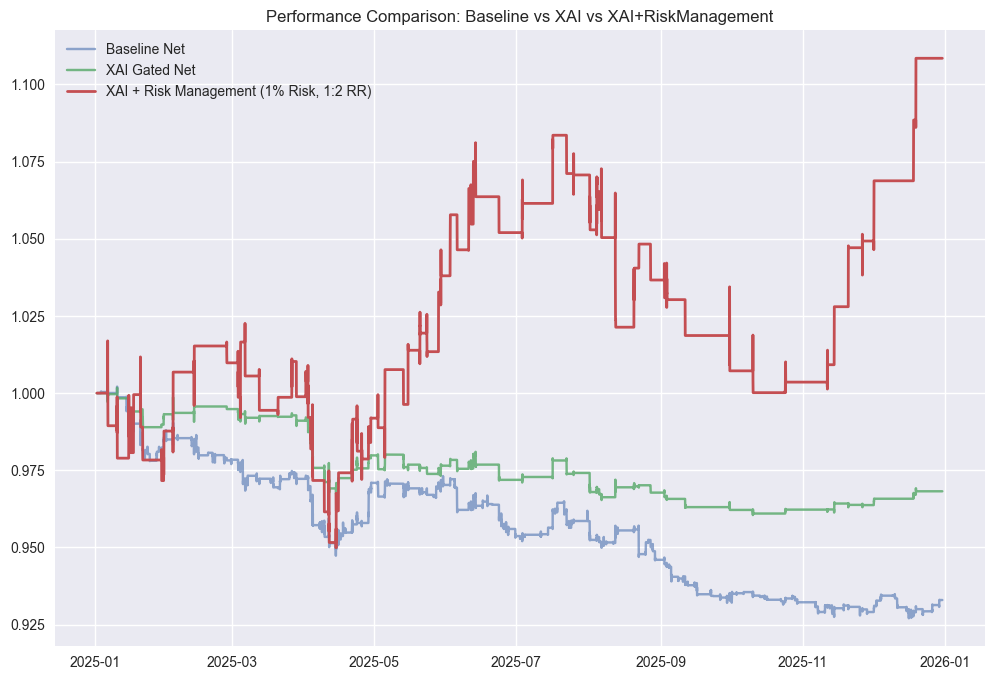


--- Risk Management System Performance ---
Final Capital: 110844.25
Total Trades: 85
Win Rate: 47.06%
Avg Win: 1274.05
Avg Loss: -891.51
Risk:Reward Realized: 1.43


In [63]:

# -------------------------------------------------------------------------------------
# RISK MANAGEMENT SYSTEM IMPLEMENTATION
# -------------------------------------------------------------------------------------
# Logic:
# 1. Capital: 100,000
# 2. Risk per Trade: 1% of Capital
# 3. Position Sizing: Risk Amount / (Entry - SL)
# 4. Target: 1:2 Risk:Reward Ratio
# 5. Stop Loss: Dynamic based on Volatility (2 * Volatility * Price) - Proxy for "Quant" approach

INITIAL_CAPITAL = 100000
RISK_PCT = 0.01
REWARD_RATIO = 2.0
LEVERAGE_CAP = 30 # Safety cap
PTC = 0.00005 # Transaction cost rate from previous cells

class RiskManagedBacktest:
    def __init__(self, df, signal_col="position_xai", price_col="price", vol_col="vol"):
        self.df = df
        self.signal_col = signal_col
        self.price_col = price_col
        self.vol_col = vol_col
        self.capital = INITIAL_CAPITAL
        self.equity = [INITIAL_CAPITAL]
        self.trades_list = []
        
    def run(self):
        # State
        position = 0 # 0, 1, -1
        entry_price = 0.0
        stop_loss = 0.0
        take_profit = 0.0
        qty = 0
        
        # We start from index 1 to allow looking at previous signal
        for i in range(1, len(self.df)):
            idx = self.df.index[i]
            
            # Current Market Data
            current_price = self.df[self.price_col].iloc[i]
            current_vol = self.df[self.vol_col].iloc[i]
            current_signal = self.df[self.signal_col].iloc[i]
            
            # Previous Signal (to detect changes)
            prev_signal = self.df[self.signal_col].iloc[i-1]
            
            # 1. MANAGE EXISTING TRADE (SL/TP)
            if position != 0:
                # Check for SL Hit (Assume hit at SL level)
                sl_hit = (position == 1 and current_price <= stop_loss) or \
                         (position == -1 and current_price >= stop_loss)
                
                # Check for TP Hit (Assume hit at TP level)
                tp_hit = (position == 1 and current_price >= take_profit) or \
                         (position == -1 and current_price <= take_profit)
                
                # Check for Signal Reversal/Exit (XAI Strategy says get out)
                # Exit if signal goes to 0 or flips direction
                sig_exit = (current_signal == 0) or (current_signal != position)
                
                exit_price = None
                exit_reason = None
                
                if sl_hit:
                    exit_price = stop_loss
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = take_profit
                    exit_reason = "TP"
                elif sig_exit:
                    exit_price = current_price
                    exit_reason = "Signal"
                
                if exit_price is not None:
                    # Calculate PnL
                    # Gross PnL
                    trade_pnl = (exit_price - entry_price) * qty * position
                    # Transaction Costs (Entry + Exit) ~ Estimated
                    commission = (qty * entry_price * PTC) + (qty * exit_price * PTC)
                    
                    net_pnl = trade_pnl - commission
                    self.capital += net_pnl
                    
                    self.trades_list.append({
                        "Entry Time": entry_time,
                        "Exit Time": idx,
                        "Type": position,
                        "Entry Price": entry_price,
                        "Exit Price": exit_price,
                        "Reason": exit_reason,
                        "PnL": net_pnl,
                        "Return %": (net_pnl / (qty * entry_price)) * 100
                    })
                    
                    # Reset State
                    position = 0
                    qty = 0
            
            # 2. CHECK FOR NEW ENTRY
            # Only enter if currently flat AND signal has CHANGED to a new active state
            # (Matches XAI Gate logic: trade on events)
            if position == 0:
                if current_signal != 0 and current_signal != prev_signal:
                    # Logic to calculate Size
                    risk_amt = self.capital * RISK_PCT
                    
                    # Determine SL Distance
                    # Use 2 * Volatility (StdDev of Returns) * Price as proxy for ATR/Swing
                    # If Vol is too low, set min floor
                    sl_dist = current_price * current_vol * 2.0
                    if sl_dist < (current_price * 0.0005): # Min 5 pips approx
                        sl_dist = current_price * 0.0005
                        
                    if current_signal == 1:
                        stop_loss = current_price - sl_dist
                        take_profit = current_price + (sl_dist * REWARD_RATIO)
                    else:
                        stop_loss = current_price + sl_dist
                        take_profit = current_price - (sl_dist * REWARD_RATIO)
                        
                    # Calculate Quantity
                    # Risk = Qty * |Entry - SL|
                    # Qty = Risk / |Entry - SL|
                    if sl_dist > 0:
                        qty = risk_amt / sl_dist
                    else:
                        qty = 0
                        
                    # Leverage Check (Optional)
                    notional = qty * current_price
                    if notional > (self.capital * LEVERAGE_CAP):
                        qty = (self.capital * LEVERAGE_CAP) / current_price
                        
                    position = current_signal
                    entry_price = current_price
                    entry_time = idx
            
            # Record Equity Curve
            # Mark-to-market equity
            open_pnl = 0
            if position != 0:
                open_pnl = (current_price - entry_price) * qty * position
            
            self.equity.append(self.capital + open_pnl)
            
        return pd.Series(self.equity, index=self.df.index[len(self.df)-len(self.equity):])

# Run the RM Backtest
rm_backtest = RiskManagedBacktest(test, signal_col="position_xai")
test['equity_rm'] = rm_backtest.run()

# Normalize for comparison plot (Start at 1.0 like others)
test['cstrategy_rm_norm'] = test['equity_rm'] / INITIAL_CAPITAL

# Plotting Comparison
plt.figure(figsize=(12, 8))
plt.plot(test['cstrategy_net'], label='Baseline Net', alpha=0.6)
plt.plot(test['cstrategy_net_xai'], label='XAI Gated Net', alpha=0.8)
plt.plot(test['cstrategy_rm_norm'], label='XAI + Risk Management (1% Risk, 1:2 RR)', linewidth=2)
plt.title("Performance Comparison: Baseline vs XAI vs XAI+RiskManagement")
plt.legend()
plt.show()

# Statistics
trades_df = pd.DataFrame(rm_backtest.trades_list)
print("\n--- Risk Management System Performance ---")
print(f"Final Capital: {test['equity_rm'].iloc[-1]:.2f}")
print(f"Total Trades: {len(trades_df)}")
if len(trades_df) > 0:
    win_rate = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df)
    avg_win = trades_df[trades_df['PnL'] > 0]['PnL'].mean()
    avg_loss = trades_df[trades_df['PnL'] <= 0]['PnL'].mean()
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Avg Win: {avg_win:.2f}")
    print(f"Avg Loss: {avg_loss:.2f}")
    print(f"Risk:Reward Realized: {abs(avg_win/avg_loss):.2f}")
else:
    print("No trades generated.")
